In [1]:
import scanpy as sc
import os

In [2]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_human_v1/'
fin = os.path.join(ddir, 'Jorstad23_human_v1_l23.h5ad')
!ls $ddir

Jorstad23_human_v1.h5ad      Jorstad_processed.h5ad
Jorstad23_human_v1_l23.h5ad  marker_genes.png


In [3]:
%%time
adata = sc.read(fin) #, backed='r')
adata

CPU times: user 1.96 s, sys: 7.38 s, total: 9.34 s
Wall time: 52.9 s


AnnData object with n_obs × n_vars = 54742 × 29352
    obs: 'Class', 'CrossArea_subclass', 'CrossArea_cluster', 'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer', 'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'donor_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP'

In [4]:
meta = adata[adata.obs['WithinArea_subclass']=='L2/3 IT'].obs
meta['WithinArea_cluster'].value_counts()

L2/3 IT_2    36081
L2/3 IT_5    13806
L2/3 IT_4     2014
L2/3 IT_3     1472
L2/3 IT_1      781
L2/3 IT_6      588
Name: WithinArea_cluster, dtype: int64

In [5]:
adata.X.data

array([4.8638215, 4.35813  , 5.888465 , ..., 4.6665444, 4.265771 ,
       4.951873 ], dtype=float32)

AnnData object with n_obs × n_vars = 54742 × 29352
    obs: 'Class', 'CrossArea_subclass', 'CrossArea_cluster', 'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer', 'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'donor_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP'
obs columns: ['Class', 'CrossArea_subclass', 'CrossArea_cluster', 'Wit

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


  Saving umap_WithinArea_subclass.png ...
  Saving umap_WithinArea_cluster.png ...


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


  Saving umap_Class.png ...
  Saving umap_Layer.png ...


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


  Saving umap_Region.png ...
Saving PCA PC1 vs PC2 plot colored by CrossArea_cluster...


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


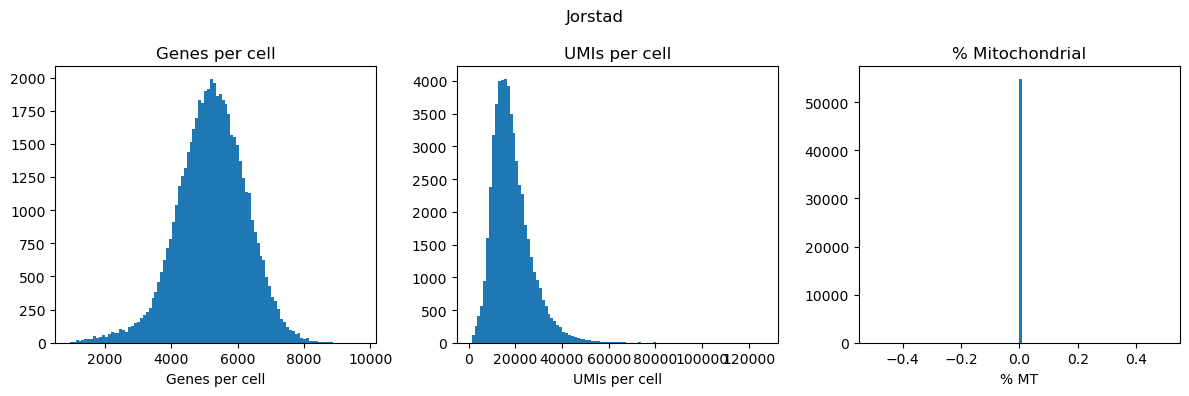

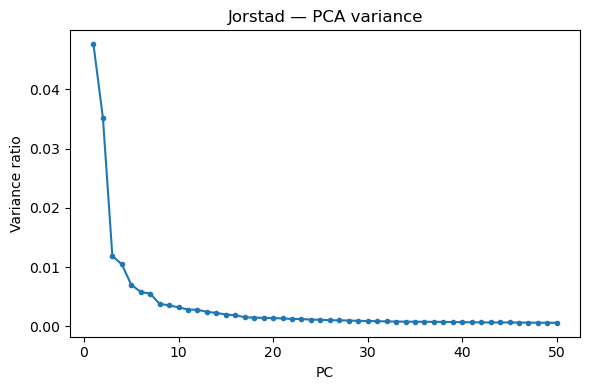

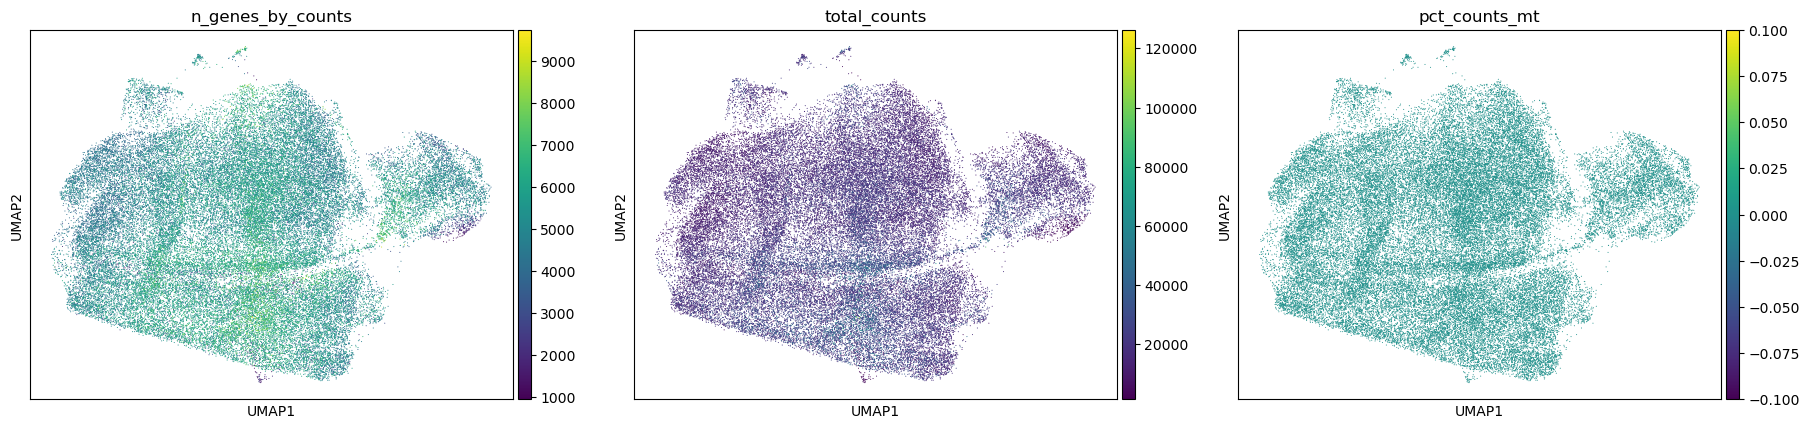

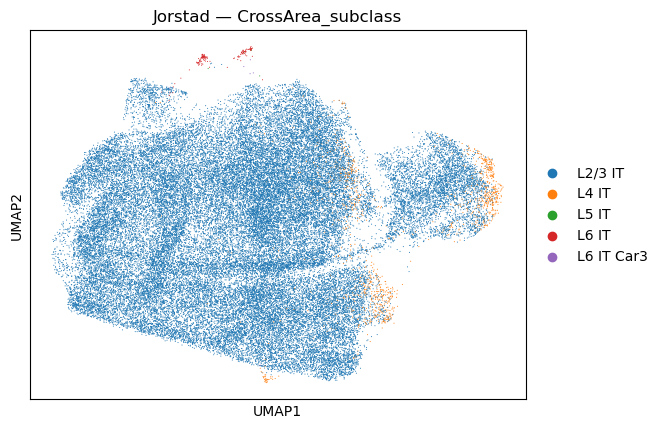

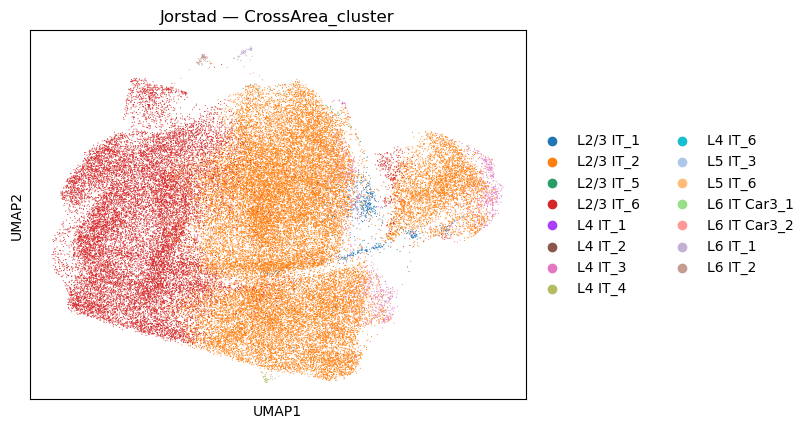

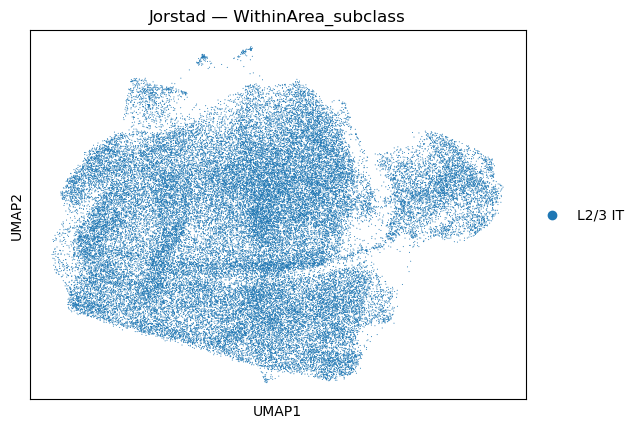

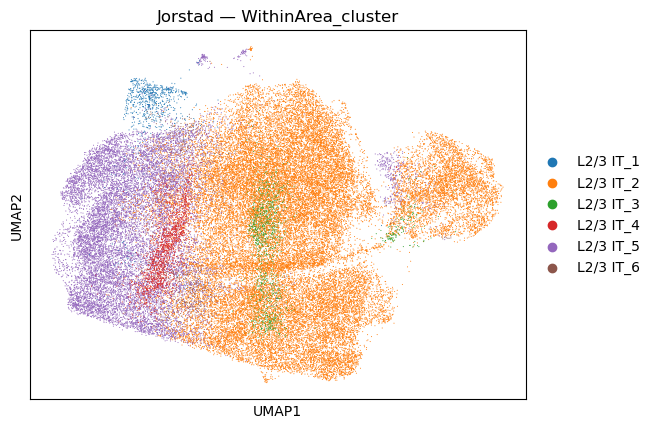

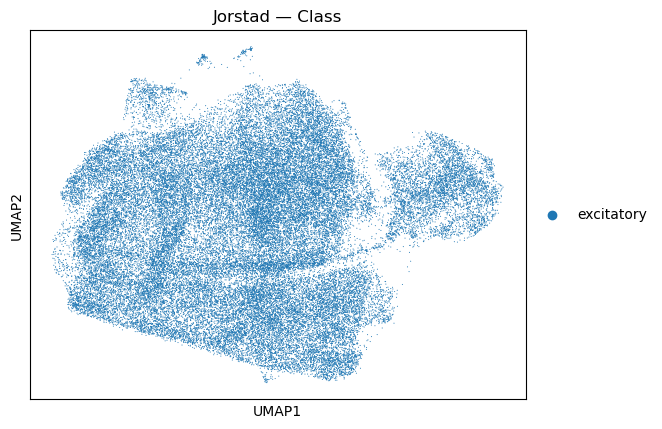

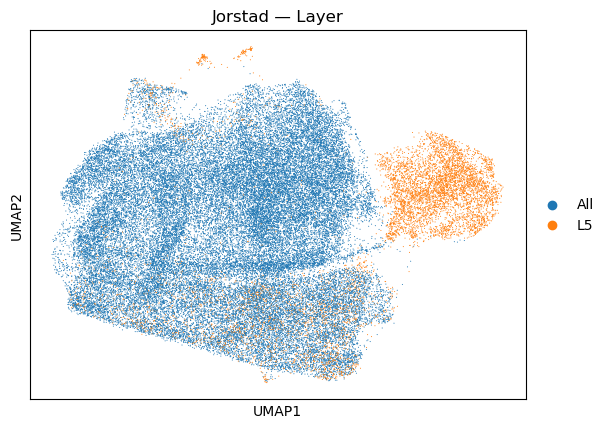

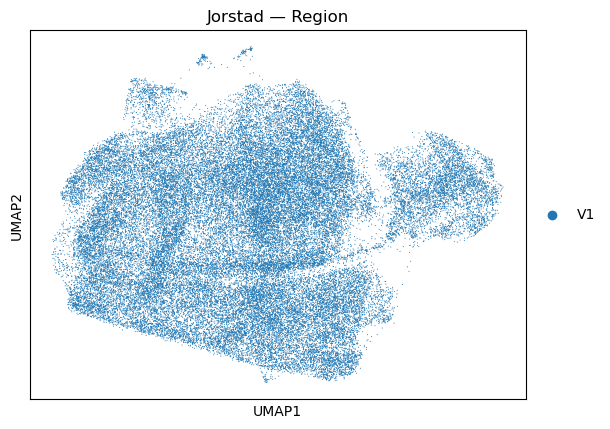

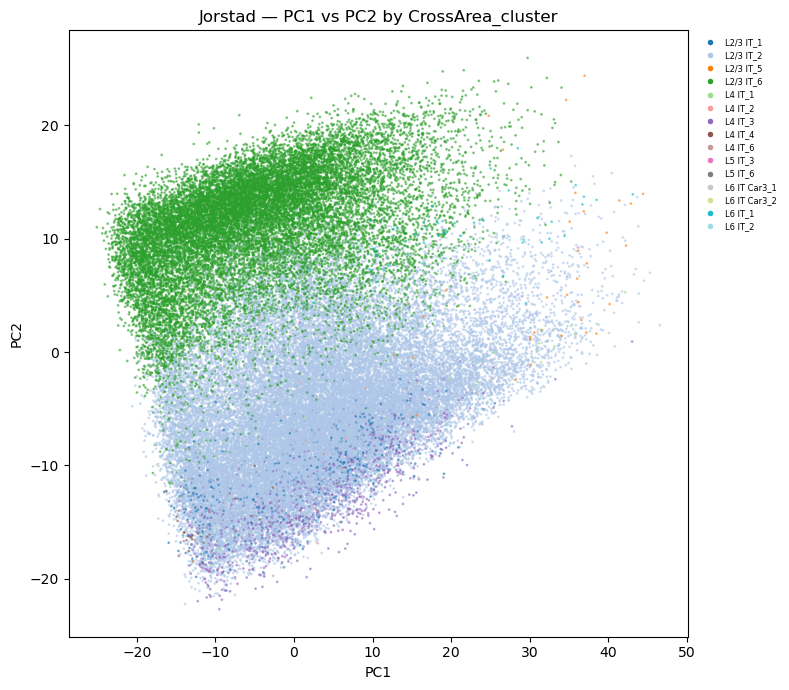

In [6]:
"""
scRNA-seq pipeline for published h5ad datasets (e.g. Jorstad23).
Handles data that may already be normalized/log-transformed.

Usage:
    python scrna_pipeline_h5ad.py --h5ad <path> --sample <name> --out_dir <dir>
"""
import argparse
import os
import numpy as np
import scanpy as sc
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt

SAMPLE    = "Jorstad"
OUT_DIR   = ddir
np.random.seed(0)

os.makedirs(OUT_DIR, exist_ok=True)
sc.settings.figdir    = OUT_DIR
sc.settings.verbosity = 2

# # ── 1. Load & detect normalization state ─────────────────────────────────────
# print(f"Loading {H5AD_PATH} ...")
# adata = sc.read_h5ad(H5AD_PATH)
# adata.var_names_make_unique()
print(adata)
print(f"obs columns: {list(adata.obs.columns)}")
print(f"var columns: {list(adata.var.columns)}")

# Detect whether data is raw (integer counts) or already normalized
def _is_integer_matrix(mat, n_sample=100):
    """Sample up to n_sample x n_sample values and check if all are integers."""
    import scipy.sparse as sp
    if sp.issparse(mat):
        sub = mat[:min(n_sample, mat.shape[0]), :min(n_sample, mat.shape[1])].toarray()
    else:
        sub = np.asarray(mat[:min(n_sample, mat.shape[0]), :min(n_sample, mat.shape[1])])
    return np.allclose(sub, np.round(sub))

already_normalized = False

if adata.raw is not None:
    raw_integer = _is_integer_matrix(adata.raw.X)
    print(f".raw exists — integer counts: {raw_integer}")
    if raw_integer:
        print("Using .raw as starting point (integer counts detected).")
        adata = adata.raw.to_adata()
    else:
        print(".raw is not integer — treating main .X as already normalized.")
        already_normalized = True
else:
    x_integer = _is_integer_matrix(adata.X)
    print(f"No .raw — .X integer counts: {x_integer}")
    if not x_integer:
        already_normalized = True
        print(".X appears normalized; skipping normalize_total + log1p.")
    else:
        print(".X appears to be raw counts; will normalize.")

print(f"already_normalized = {already_normalized}")

# ── 2. QC metrics ─────────────────────────────────────────────────────────────
print("Computing QC metrics...")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[0].set_xlabel("Genes per cell"); axes[0].set_title("Genes per cell")
axes[1].hist(adata.obs["total_counts"], bins=100)
axes[1].set_xlabel("UMIs per cell"); axes[1].set_title("UMIs per cell")
axes[2].hist(adata.obs["pct_counts_mt"], bins=100)
axes[2].set_xlabel("% MT"); axes[2].set_title("% Mitochondrial")
fig.suptitle(SAMPLE)
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/qc_histograms.png", dpi=150)
# plt.close()
print(f"  n_genes_by_counts: median={adata.obs['n_genes_by_counts'].median():.0f}, "
      f"mean={adata.obs['n_genes_by_counts'].mean():.0f}")

# ── 3. Gene filter only (cells already QC-passed in published dataset) ────────
print("Filtering genes...")
sc.pp.filter_genes(adata, min_cells=3)
print(f"After gene filter: {adata.shape}")

# ── 4. Normalize + log1p (skip if already normalized) ────────────────────────
if not already_normalized:
    print("Normalizing...")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
else:
    print("Skipping normalize_total + log1p (data already normalized).")

# ── 5. Highly variable genes ──────────────────────────────────────────────────
print("Finding highly variable genes...")
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
n_hvg = adata.var.highly_variable.sum()
print(f"Highly variable genes: {n_hvg}")
if n_hvg < 500:
    print("WARNING: fewer than 500 HVGs — consider loosening HVG parameters.")

adata.raw = adata  # freeze before subsetting to HVGs
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG subset: {adata.shape}")

# ── 6. Regress out + scale ────────────────────────────────────────────────────
# print("Regressing out covariates...")
# regress_vars = ["total_counts"]
# if adata.obs["pct_counts_mt"].max() > 0:
#     regress_vars.append("pct_counts_mt")
# print(f"  regress_out vars: {regress_vars}")
# sc.pp.regress_out(adata, regress_vars)
sc.pp.scale(adata, max_value=10)

# ── 7. PCA ────────────────────────────────────────────────────────────────────
print("PCA...")
sc.tl.pca(adata, svd_solver="arpack")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, 51), adata.uns["pca"]["variance_ratio"][:50], "o-", ms=3)
ax.set_xlabel("PC"); ax.set_ylabel("Variance ratio"); ax.set_title(f"{SAMPLE} — PCA variance")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/pca_variance.png", dpi=150)
# plt.close()

# ── 8. Neighbors + UMAP ───────────────────────────────────────────────────────
print("Computing neighbors and UMAP...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# # ── 9. Leiden clustering ──────────────────────────────────────────────────────
# print("Leiden clustering...")
# sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)
# n_clusters = adata.obs["leiden"].nunique()
# print(f"Leiden clusters: {n_clusters}")

# ── 10. UMAP plots ────────────────────────────────────────────────────────────
print("Saving UMAP plots...")

# fig = sc.pl.umap(adata, color="leiden", legend_loc="on data",
#                  title=f"{SAMPLE} — {n_clusters} Leiden clusters",
#                  show=False, return_fig=True)
# fig.savefig(f"{OUT_DIR}/umap_leiden.png", dpi=150, bbox_inches="tight")
# plt.close()

fig = sc.pl.umap(adata, color=["n_genes_by_counts", "total_counts", "pct_counts_mt"],
                 ncols=3, show=False, return_fig=True)
# fig.savefig(f"{OUT_DIR}/umap_qc.png", dpi=150, bbox_inches="tight")
# plt.close()

# UMAP colored by original annotation columns (if present)
ANNOT_COLS = [
    "subclass_label", "cluster_label", "class_label",
    "CrossArea_subclass", "CrossArea_cluster",
    "WithinArea_subclass", "WithinArea_cluster",
    "Class", "Layer", "Region",
]
for col in ANNOT_COLS:
    if col in adata.obs.columns:
        print(f"  Saving umap_{col}.png ...")
        fig = sc.pl.umap(adata, color=col, title=f"{SAMPLE} — {col}",
                         show=False, return_fig=True)
        # fig.savefig(f"{OUT_DIR}/umap_{col}.png", dpi=150, bbox_inches="tight")
        # plt.close()

# ── 11. PCA scatter PC1 vs PC2 colored by cluster annotation ────────────────
# Try cluster_label first, then Jorstad23-specific equivalents
_cluster_col = next(
    (c for c in ["CrossArea_cluster", "WithinArea_cluster"]
     if c in adata.obs.columns),
    None,
)
if _cluster_col is not None:
    print(f"Saving PCA PC1 vs PC2 plot colored by {_cluster_col}...")
    pca_coords = adata.obsm["X_pca"]
    cluster_vals = adata.obs[_cluster_col].astype(str)
    unique_clusters = sorted(cluster_vals.unique())
    cmap = plt.get_cmap("tab20", len(unique_clusters))
    cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
    colors = [cmap(cluster_to_idx[c]) for c in cluster_vals]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1],
               c=colors, s=1, alpha=0.5, rasterized=True)
    # Legend (only show up to 30 clusters to avoid clutter)
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=cmap(cluster_to_idx[c]),
                           markersize=5, label=c)
               for c in unique_clusters[:30]]
    ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=6, frameon=False)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"{SAMPLE} — PC1 vs PC2 by {_cluster_col}")
    fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/pca_pc1_pc2_{_cluster_col}.png", dpi=150, bbox_inches="tight")
    # plt.close()




Finding marker genes (Wilcoxon)...
ranking genes
    finished (0:04:37)
Saving to /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_human_v1//Jorstad_processed.h5ad ...
Done.


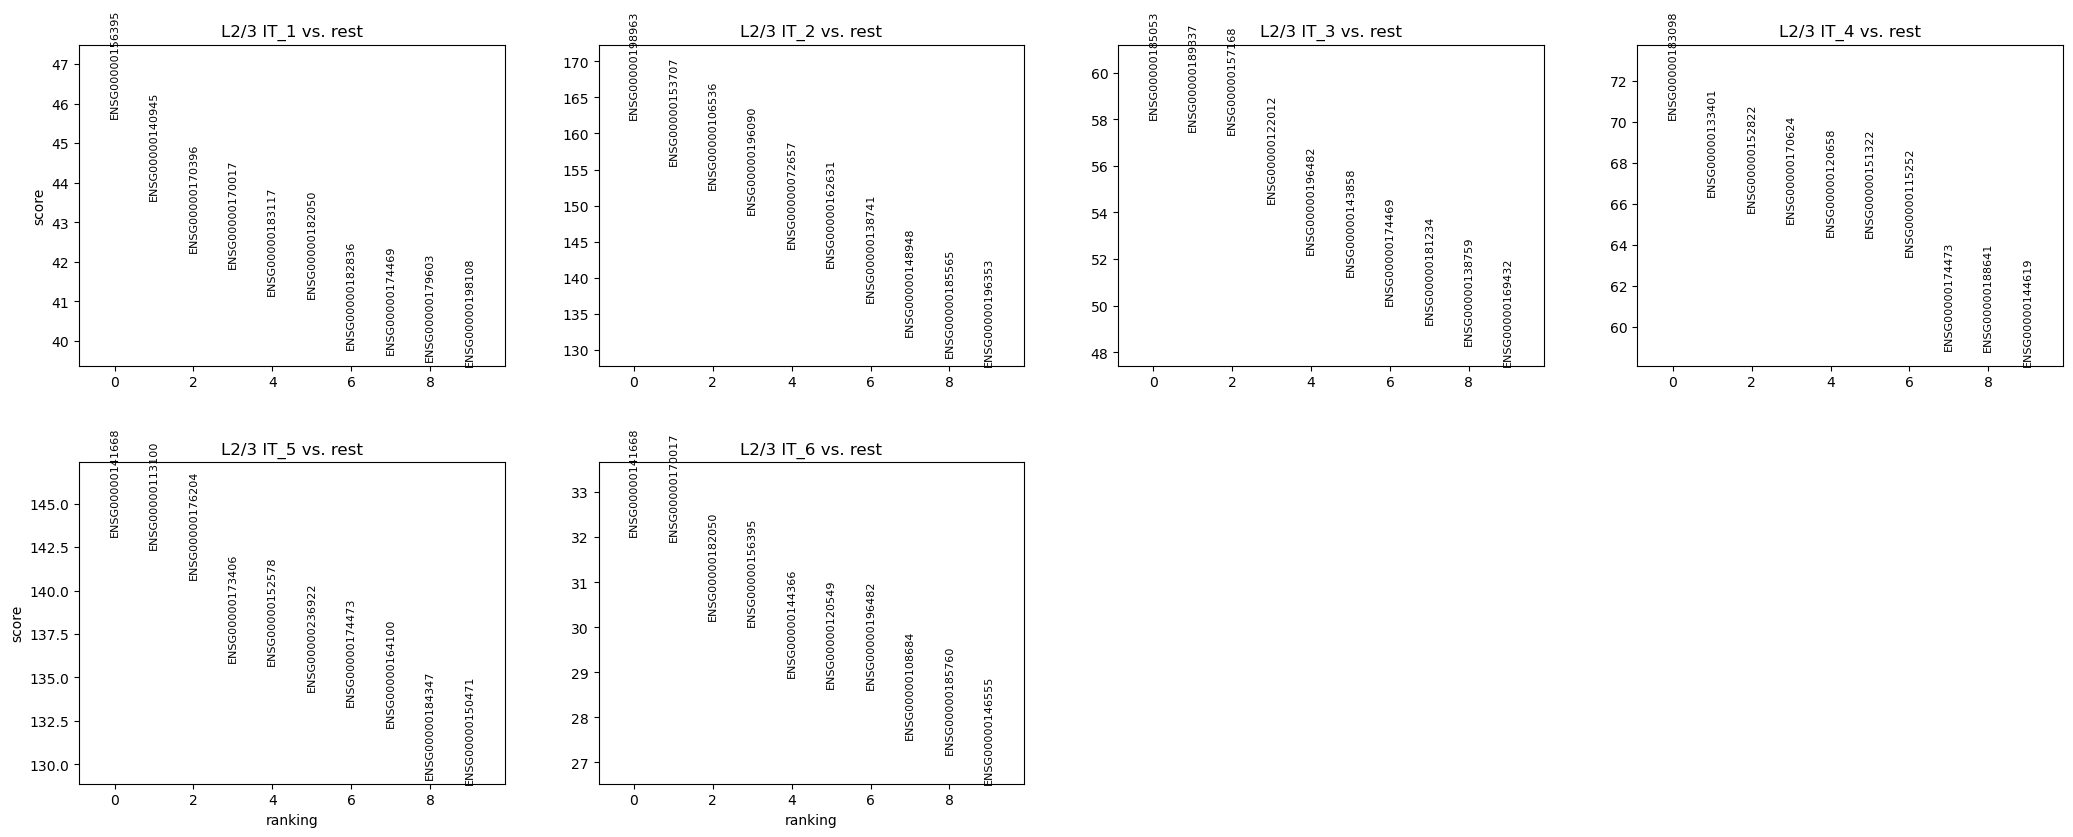

In [7]:
# ── 12. Marker genes ─────────────────────────────────────────────────────────
print("Finding marker genes (Wilcoxon)...")
sc.tl.rank_genes_groups(adata, "WithinArea_cluster", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, show=False)
plt.savefig(f"{OUT_DIR}/marker_genes.png", dpi=150, bbox_inches="tight")
# plt.close("all")

# ── 13. Save ──────────────────────────────────────────────────────────────────
out_h5ad = f"{OUT_DIR}/{SAMPLE}_processed.h5ad"
print(f"Saving to {out_h5ad} ...")
adata.write_h5ad(out_h5ad)
print("Done.")

In [8]:
adata

AnnData object with n_obs × n_vars = 54742 × 2703
    obs: 'Class', 'CrossArea_subclass', 'CrossArea_cluster', 'WithinArea_subclass', 'WithinArea_cluster', 'Source', 'Layer', 'Location', 'Region', 'Subregion', 'nCount_RNA', 'nFeature_RNA', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'donor_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_